# Model-Free Control: Tabular Methods
In this notebook, we explore model-free **CONTROL** algorithms. The goal here shifts from evaluating a specific policy, to finding the optimal policy $ \pi^*(s) $ for our maze-environment. As in model-free evaluation setup, the agent has no knowledge of the dynamics of the environment and the learning process is developed exclusively by interacting with the environment, episode by episode.

In [1]:
import time
from IPython.display import display, clear_output

from envs.maze_env import MazeEnv, UP, DOWN, LEFT, RIGHT
from envs.windy_maze_env import WindyMazeEnv, UP, DOWN, LEFT, RIGHT
from algorithms.monte_carlo_control import MonteCarloControl
from algorithms.sarsa_control import SarsaControl
from algorithms.q_learning_control import QLearningControl
from utils.visualization import plot_grid, plot_policy, plot_combined_chart, plot_q_values

## 1. Environment Setup
Let's set up our Maze environment layout. We are introducing one additional feature to our environment: an explicit and stochastic transition probability matrix $P(s', r | s, a)$. So far, we have assumed that the agent's policy was stochastic but the dynamic of the environment was deterministic: whatever action chosen by the agent, the environment would always transition to the same state. Now, we are going to allow the environment to introduce itself a stochastic behaviour: given a state and an action, the environment might transition to a new state with some probability $p(s' | s, a)$. We are implementing this idea by having an area in our Maze affected by a *"wind effect"*: in this area, independently on the agent's action, the environment will impose a probability of following one direction, the direction of the wind.

In [2]:
# 1. Setup the environment
maze_layout = [
    ['S', '.', '.', 'X', '.', '.', '.'],
    ['.', '.', '.', 'X', '.', 'X', '.'],
    ['X', '.', '.', 'X', '.', 'X', '.'],
    ['.', '.', '.', 'X', '.', 'X', '.'],
    ['.', '.', 'X', 'X', '.', 'X', '.'],
    ['.', '.', '.', '.', '.', 'X', 'G'],
]

# 2. Define the reward function
REWARD_STEP = -0.25
REWARD_GOAL = 10.0
REWARD_WALL = -0.25

# Optional: Define wind map
WIND_MAP = {
    (0, 1): (UP, 0.60),
    (0, 2): (UP, 0.60),
    (1, 1): (UP, 0.60),
    (1, 2): (UP, 0.60),
    (2, 1): (UP, 0.60),
    (2, 2): (UP, 0.60),
    (3, 1): (UP, 0.60),
    (3, 2): (UP, 0.60),
    (4, 1): (UP, 0.60),
    (4, 2): (UP, 0.60),
    (5, 1): (UP, 0.60),
    (5, 2): (UP, 0.60),
}

# Initialize the Maze
env = WindyMazeEnv(maze_layout=maze_layout, 
            reward_step=REWARD_STEP, 
            reward_goal=REWARD_GOAL, 
            reward_wall=REWARD_WALL,
            wind_map=WIND_MAP)

# 3. Define discount factor
GAMMA = 0.90

## 2. Monte Carlo Control
We start by training the agent to find the optimal policy using Monte Carlo Control algorithm.
We will run many episodes using an epsilon-greedy policy to learn the action-value function $Q(s,a)$. Finally we will extract the optimal policy from $Q^*(s,a)$. Notice that the greedy parameter *epsilon* is decaying from the starting value of 1.0, episode by episode, to ensure proper convergence of the solution.

In [3]:
max_episodes = 2000
# Initialize MC Control agent
mc_control = MonteCarloControl(env, gamma=GAMMA, epsilon=1.0, epsilon_min=0.075, epsilon_decay=0.995)
# Train MC Control agent
optimal_policy, Q_values = mc_control.train(num_episodes=max_episodes, max_steps=500, first_visit=True, verbose=True)

Monte Carlo Control completed 2000 episodes in 2.2485 seconds.
Goal reached 0 times (0.00%).
Final epsilon: 0.0750


### 2.1 Monte Carlo Control - Optimal Policy
Let's visualize the optimal policy learned by the algorithm. The arrows indicate the best action in each state. Notice that since *epsilon* - the source of our exploration incentive - is decaying as episodes pass, then there are less and less incentives to explore new states than the dominant ones. Hence some states might have a final optimal policy which is different than the *true* $Q^*(s, a)$, simply due to poor exploration of those states.

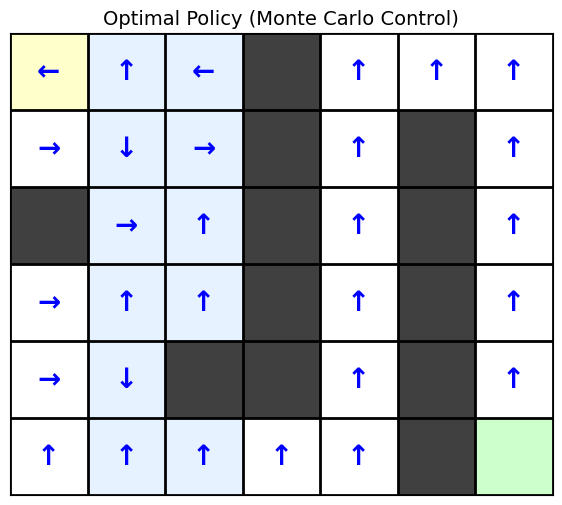

In [4]:
# Convert deterministic policy format back to probability distribution (100%) for plotting
plotable_policy = {}
for state, action in optimal_policy.items():
    plotable_policy[state] = {action: 1.0}
    
plot_policy(env, "Monte Carlo Control", plotable_policy, wind_map=WIND_MAP)

### 2.2 Monte Carlo Control - Path, Performance and Q-Value Map ep. by ep.
We can visually analyse the learning process of the agent by animating different variables created by the agent's experience in the environemnt episode by episode. As experiences is gathered, the agent should be able to improve its policy, obtain more rewards and reaching the goal more often. We will plot the behaviour of the paths walked by the agent, the evolution of the *Q-Value* map and the total rewards (as average reward per step) per episode. These measures should allow us to understand whether the agent was actually able to learn the optimal policy during after the training phase

In [5]:
# Configuration variables
step_size = 50
algorithm_name = "MC Control"
history = mc_control.Q_history
total_episodes = len(mc_control.paths)

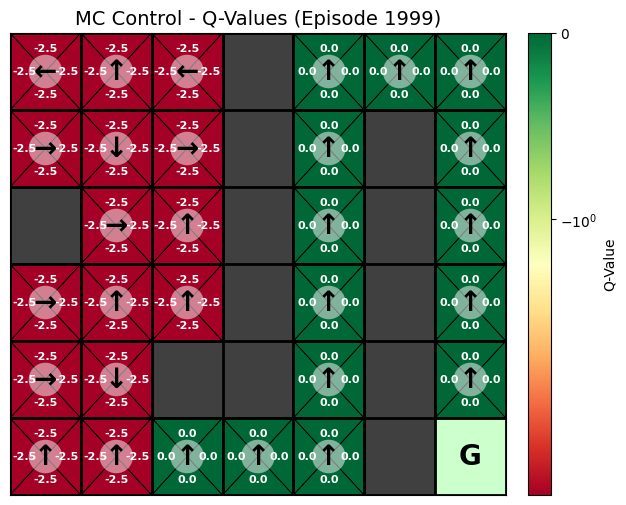

Finished run.


In [6]:
# Iterate through the history and animate the Q-value maps
for i in range(0, len(history), step_size):
    
    clear_output(wait=True)
    plot_q_values(env, algorithm_name, history[i], i)
    time.sleep(1)   # change this param to increase / decrease the speed of updates.

# Guarantee the final converged state is printed at the very end
clear_output(wait=True)
plot_q_values(env, algorithm_name, history[-1], len(history) - 1)
print("Finished run.")

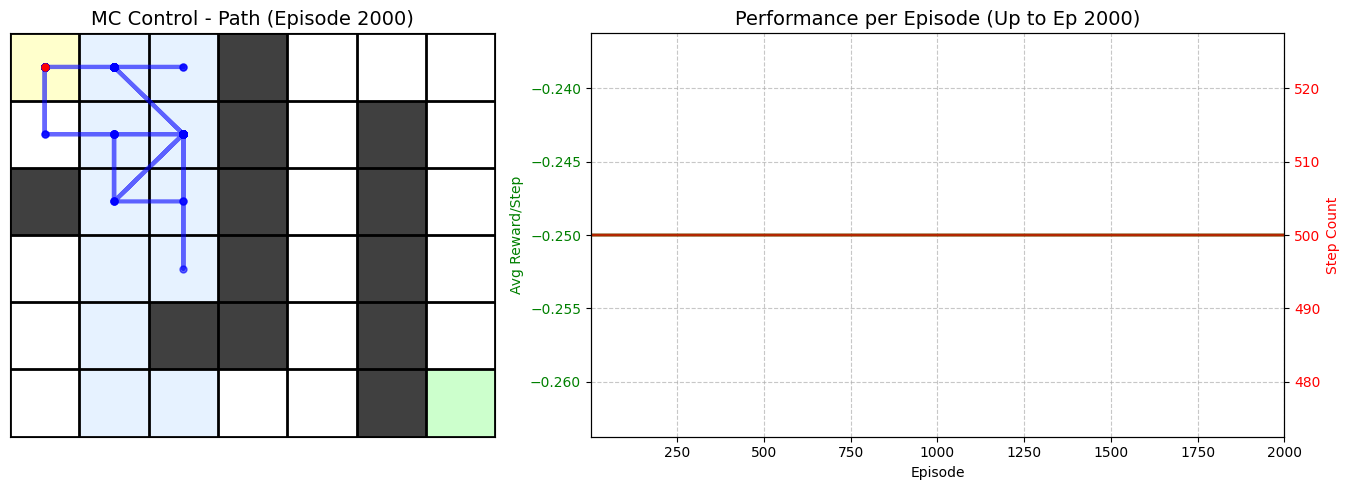

Finished run.


In [7]:
# Run the visualization loop and show the behaviour of the path and of the performance
for i in range(0, total_episodes, step_size):
    
    clear_output(wait=True)
    plot_combined_chart(
        env=env, 
        algorithm=algorithm_name, 
        path=mc_control.paths[i], 
        episode=i + 1, 
        rewards_up_to_now=mc_control.episode_rewards[:i+1],
        lengths_up_to_now=mc_control.episode_lengths[:i+1],
        wind_map=WIND_MAP
    )
    time.sleep(0.5)

# Plot the final frame (ensures we see the very last episode)
clear_output(wait=True)
plot_combined_chart(
    env=env, 
    algorithm=algorithm_name, 
    path=mc_control.paths[-1], 
    episode=total_episodes, 
    rewards_up_to_now=mc_control.episode_rewards,
    lengths_up_to_now=mc_control.episode_lengths,
    wind_map=WIND_MAP
)
print("Finished run.")

## 3. SARSA Control
As we did for other algorithms, Monte Carlo is just one of the approaches we can take. One other natural solution is based on temporal differences and it's called SARSA. This name comes from the tuple (state - action - reward - next state - next action) which is the information we are using in SARSA algorithm when updating our $Q(s,a)$ function. The idea is inspired by TD(0): we look ahead one step, gather the reward and observe our next state and action, then we update the $Q(s,a)$ function in that direction via a lerning rate. We are still going to use an *epsilon* parameter for the trade-off between exploration and exploitation and we need to explicitely introduce an *alpha* parameter serving as a learning rate for the singular update.

In [8]:
max_episodes = 2000
ALPHA = 0.1

# Initialize SARSA 
# We added alpha (aka learning rate) parameter because TD-based methods rely also on this parameter:
sarsa_control = SarsaControl(env, gamma=GAMMA, alpha=ALPHA, epsilon=1.0, epsilon_min=0.075, epsilon_decay=0.995)
# Train SARSA
optimal_policy, Q_values = sarsa_control.train(num_episodes=max_episodes, max_steps=500, verbose=True)

SARSA Control completed 2000 episodes in 0.2569 seconds.
Goal reached 1899 times (94.95%).
Final epsilon: 0.0750


### 3.1 SARSA Control - Optimal Policy

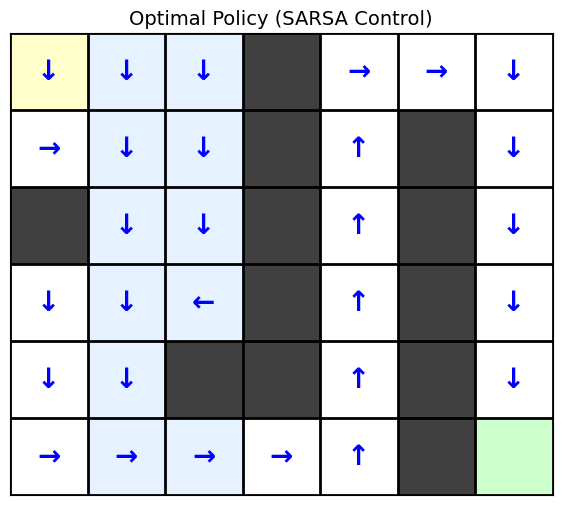

In [9]:
# Convert deterministic policy format back to probability distribution (100%) for plotting
plotable_policy = {}
for state, action in optimal_policy.items():
    plotable_policy[state] = {action: 1.0}

plot_policy(env, "SARSA Control", plotable_policy, wind_map=WIND_MAP)

### 3.2 SARSA Control - Path, Performance and Q-Value Map ep. by ep.

In [10]:
# Configuration variables
step_size = 50
algorithm_name = "SARSA Control"
history = sarsa_control.Q_history
total_episodes = len(sarsa_control.paths)

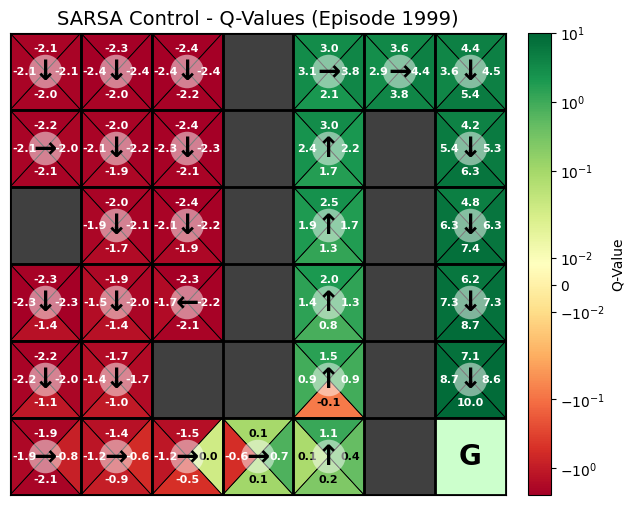

Finished run.


In [11]:
# Iterate through the history and animate the Q-value maps
for i in range(0, len(history), step_size):

    clear_output(wait=True)  # This deletes the previous plot before showing the new one
    plot_q_values(env, algorithm_name, history[i], i)
    time.sleep(1)   # change this param to increase / decrease the speed of updates.

# Guarantee the final converged state is printed at the very end
clear_output(wait=True)
plot_q_values(env, algorithm_name, history[-1], len(history) - 1)
print("Finished run.")

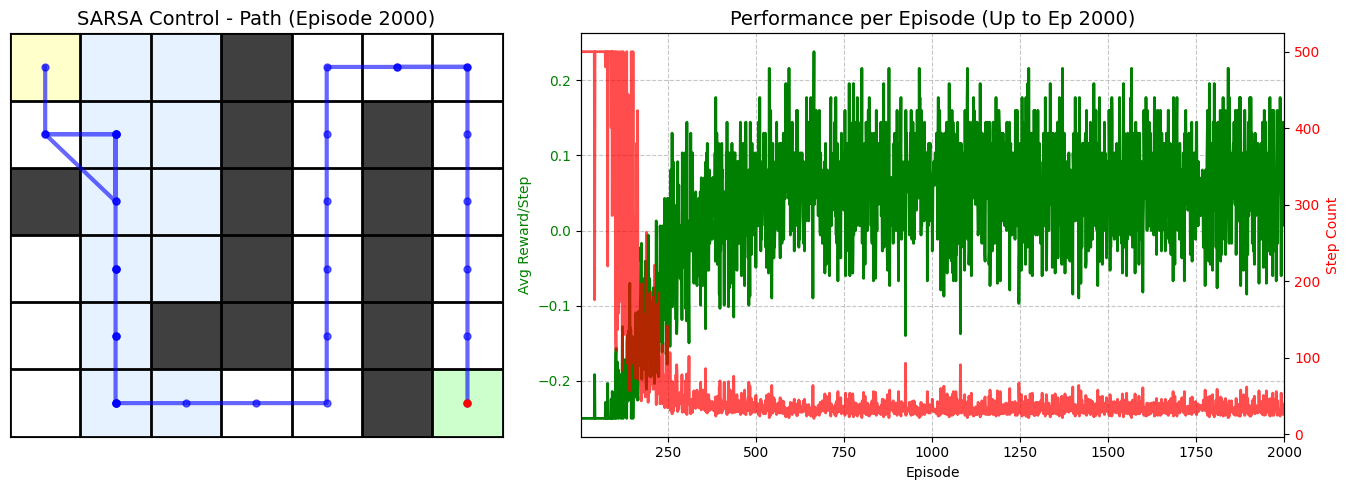

Finished run.


In [12]:
# Run the visualization loop
for i in range(0, total_episodes, step_size):

    clear_output(wait=True)
    plot_combined_chart(
        env=env, 
        algorithm="SARSA Control", 
        path=sarsa_control.paths[i], 
        episode=i + 1, 
        rewards_up_to_now=sarsa_control.episode_rewards[:i+1],
        lengths_up_to_now=sarsa_control.episode_lengths[:i+1],
        wind_map=WIND_MAP
    )
    time.sleep(0.5)

# Plot the final condition frame (ensures we see the very last episode)
clear_output(wait=True)
plot_combined_chart(
    env=env, 
    algorithm="SARSA Control", 
    path=sarsa_control.paths[-1], 
    episode=total_episodes, 
    rewards_up_to_now=sarsa_control.episode_rewards,
    lengths_up_to_now=sarsa_control.episode_lengths,
    wind_map=WIND_MAP
)
print("Finished run.")

## 4. Q-LEARNING
This is the first algorithm following a very different logic: so far we have implemented algorithms applying *on-policy* strategies that is, they use their own policy to improve the policy itself. Q-Learning instead is an *off-policy* algorithm which exploits another policy when updating the current policy. In particuar, Q-Learning is targeting a greedy policy, hence it updates the current policy a bit in the direction of the "best" possible action available. In practice, this approach is pretty effective in reaching an optimal solution. We will still use both an *epsilon* parameter governing the trade off between exploration and exploitation, and a *alpha* parameter as learning rate.

In [13]:
max_episodes = 2000
ALPHA = 0.1

# Initialize Q-Learning Agent
q_learning_control = QLearningControl(env, gamma=GAMMA, alpha=ALPHA, epsilon=1.0, epsilon_min=0.075, epsilon_decay=0.995)
# Train Q-Learning Agent
optimal_policy, Q_values = q_learning_control.train(num_episodes=max_episodes, max_steps=500, verbose=True)

Q-Learning Control completed 2000 episodes in 0.2173 seconds.
Goal reached 1890 times (94.50%).
Final epsilon: 0.0750


### 4.1 Q-Learning - Optimal Policy

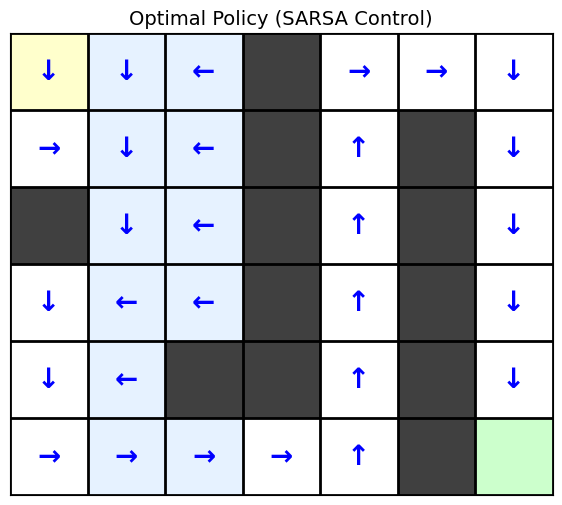

In [14]:
# Convert deterministic policy format back to probability distribution (100%) for plotting
plotable_policy = {}
for state, action in optimal_policy.items():
    plotable_policy[state] = {action: 1.0}

plot_policy(env, "SARSA Control", plotable_policy, wind_map=WIND_MAP)

### 3.2 Q-Learning - Path, Performance and Q-Value Map ep. by ep.

In [15]:
# Configuration variables
step_size = 50
algorithm_name = "Q-Learning"
history = q_learning_control.Q_history
total_episodes = len(q_learning_control.paths)

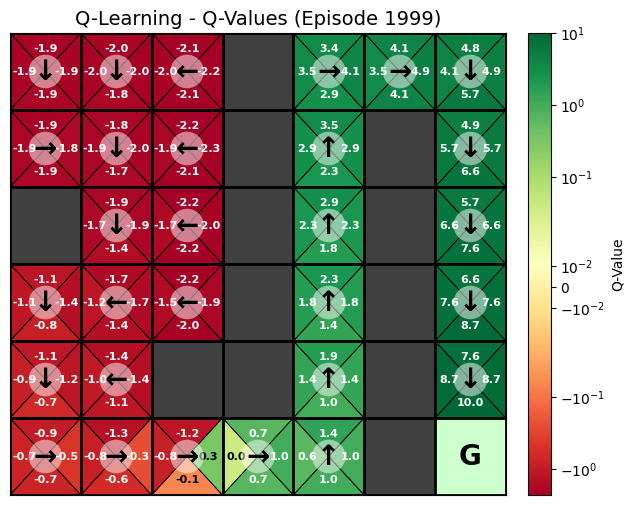

Finished run.


In [16]:
# Iterate through the history and animate the Q-value maps
for i in range(0, len(history), step_size):

    clear_output(wait=True)
    plot_q_values(env, algorithm_name, history[i], i)
    time.sleep(1)

# Guarantee the final converged state is printed at the very end
if (len(history) - 1) % step_size != 0:
    clear_output(wait=True)
    plot_q_values(env, algorithm_name, history[-1], len(history) - 1)
    print("Finished run.")

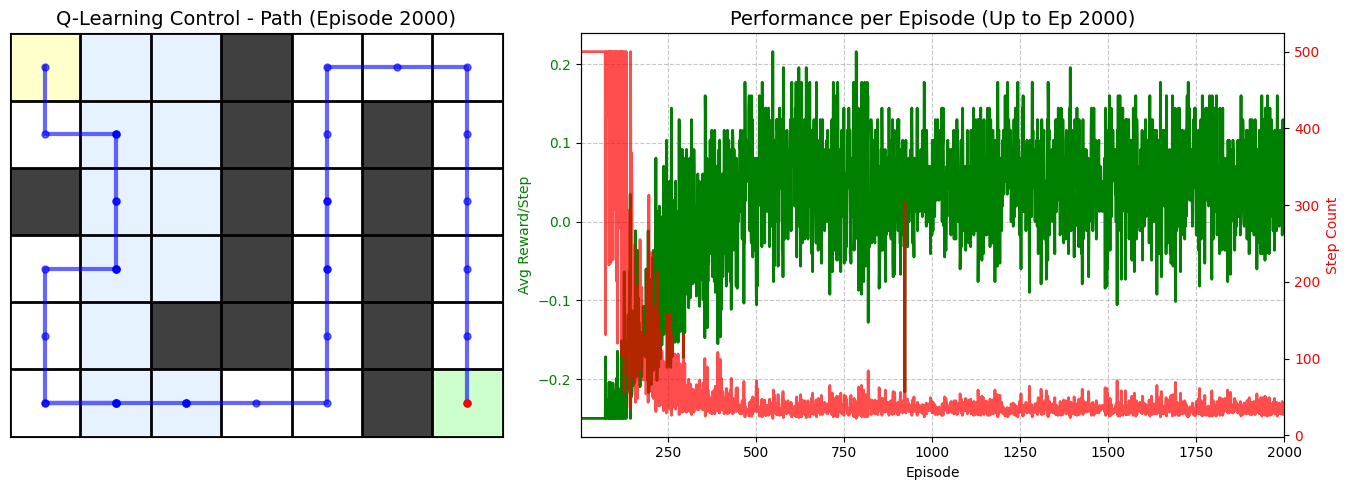

Finished run.


In [17]:
# Run the visualization loop
for i in range(0, total_episodes, step_size):
    clear_output(wait=True)
    plot_combined_chart(
        env=env, 
        algorithm="Q-Learning Control", 
        path=q_learning_control.paths[i], 
        episode=i + 1, 
        rewards_up_to_now=q_learning_control.episode_rewards[:i+1],
        lengths_up_to_now=q_learning_control.episode_lengths[:i+1],
        wind_map=WIND_MAP
    )
    time.sleep(0.5)
# Plot the final condition frame (ensures we see the very last episode)
clear_output(wait=True)
plot_combined_chart(
    env=env, 
    algorithm="Q-Learning Control", 
    path=q_learning_control.paths[-1], 
    episode=total_episodes, 
    rewards_up_to_now=q_learning_control.episode_rewards,
    lengths_up_to_now=q_learning_control.episode_lengths,
    wind_map=WIND_MAP
)
print("Finished run.")